### Initialisation : Nettoyage et Merge

In [ ]:
import pandas as pd
import numpy as np

# 1. Chargement des données 
path_cardio = "../data/raw/cardio_train.csv"
path_nhanes = "../data/raw/Nhanes_cvd_raw.csv"

df_cardio = pd.read_csv(path_cardio, sep=';')
df_nhanes = pd.read_csv(path_nhanes)

# 2. Préparation du "Pont" de fusion sur cardio_train
# Conversion de l'âge de jours en années pour matcher NHANES
df_cardio['age_years'] = (df_cardio['age'] / 365.25).astype(int)

# Création de tranches d'âge (Bins) de 5 ans pour stabiliser les moyennes
age_bins = [0, 30, 35, 40, 45, 50, 55, 60, 65, 100]
age_labels = ['0-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65+']

df_cardio['age_group'] = pd.cut(df_cardio['age_years'], bins=age_bins, labels=age_labels)
df_nhanes['age_group'] = pd.cut(df_nhanes['Age'], bins=age_bins, labels=age_labels)

# 3. Calcul des moyennes par profil dans NHANES
# Nous allons prendre la Protéine C-réactive et le Sodium par groupe d'âge et IMC
# Création d'un bin IMC simplifié dans les deux datasets
def get_bmi_cat(bmi):
    if bmi < 18.5: return 'Underweight'
    if bmi < 25: return 'Normal'
    if bmi < 30: return 'Overweight'
    return 'Obese'

# Calcul de l'IMC pour cardio_train avant le binning
df_cardio['bmi'] = df_cardio['weight'] / ((df_cardio['height'] / 100) ** 2)
df_cardio['bmi_cat'] = df_cardio['bmi'].apply(get_bmi_cat)
df_nhanes['bmi_cat'] = df_nhanes['BMI'].apply(get_bmi_cat)

# Création du dictionnaire de référence (Lookup Table) depuis NHANES
# On groupe par age_group et bmi_cat pour avoir des profils fins
reference_table = df_nhanes.groupby(['age_group', 'bmi_cat'])[['C_Reactive', 'Sodium', 'Saturated_Fat']].mean().reset_index()

# 4. Merge statistique (Fusion)
# On injecte les données moyennes de NHANES dans notre dataset principal
df_merged = pd.merge(
    df_cardio, 
    reference_table, 
    on=['age_group', 'bmi_cat'], 
    how='left'
)

# 5. Sauvegarde du dataset enrichi dans 'processed'
output_path = "../data/processed/df_merged.csv"
df_merged.to_csv(output_path, index=False)

print(f"Fusion terminée ! Dataset sauvegardé dans : {output_path}")
print(f"Nouvelles colonnes ajoutées : C_Reactive, Sodium, Saturated_Fat")
print(df_merged[['id', 'age_years', 'bmi_cat', 'C_Reactive', 'Sodium']].head())


C:\Users\louis\AppData\Local\Temp\ipykernel_6188\618301645.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reference_table = df_nhanes.groupby(['age_group', 'bmi_cat'])[['C_Reactive', 'Sodium', 'Saturated_Fat']].mean().reset_index()


Fusion terminée ! Dataset sauvegardé dans : ../data/processed/df_merged.csv
Nouvelles colonnes ajoutées : C_Reactive, Sodium, Saturated_Fat
   id  age_years     bmi_cat  C_Reactive       Sodium
0   0         50      Normal    2.216181  3373.440476
1   1         55       Obese    6.242231  3317.237500
2   2         51      Normal    2.162735  3304.609137
3   3         48  Overweight    3.325836  3542.421053
4   4         47      Normal    2.216181  3373.440476


--- % de valeurs manquantes ---
id               0.0
age              0.0
gender           0.0
height           0.0
weight           0.0
ap_hi            0.0
ap_lo            0.0
cholesterol      0.0
gluc             0.0
smoke            0.0
alco             0.0
active           0.0
cardio           0.0
age_years        0.0
age_group        0.0
bmi              0.0
bmi_cat          0.0
C_Reactive       0.0
Sodium           0.0
Saturated_Fat    0.0
dtype: float64


C:\Users\louis\AppData\Local\Temp\ipykernel_15384\2558858805.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='viridis')
C:\Users\louis\AppData\Local\Temp\ipykernel_15384\2558858805.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='C_Reactive', data=df, palette='coolwarm')


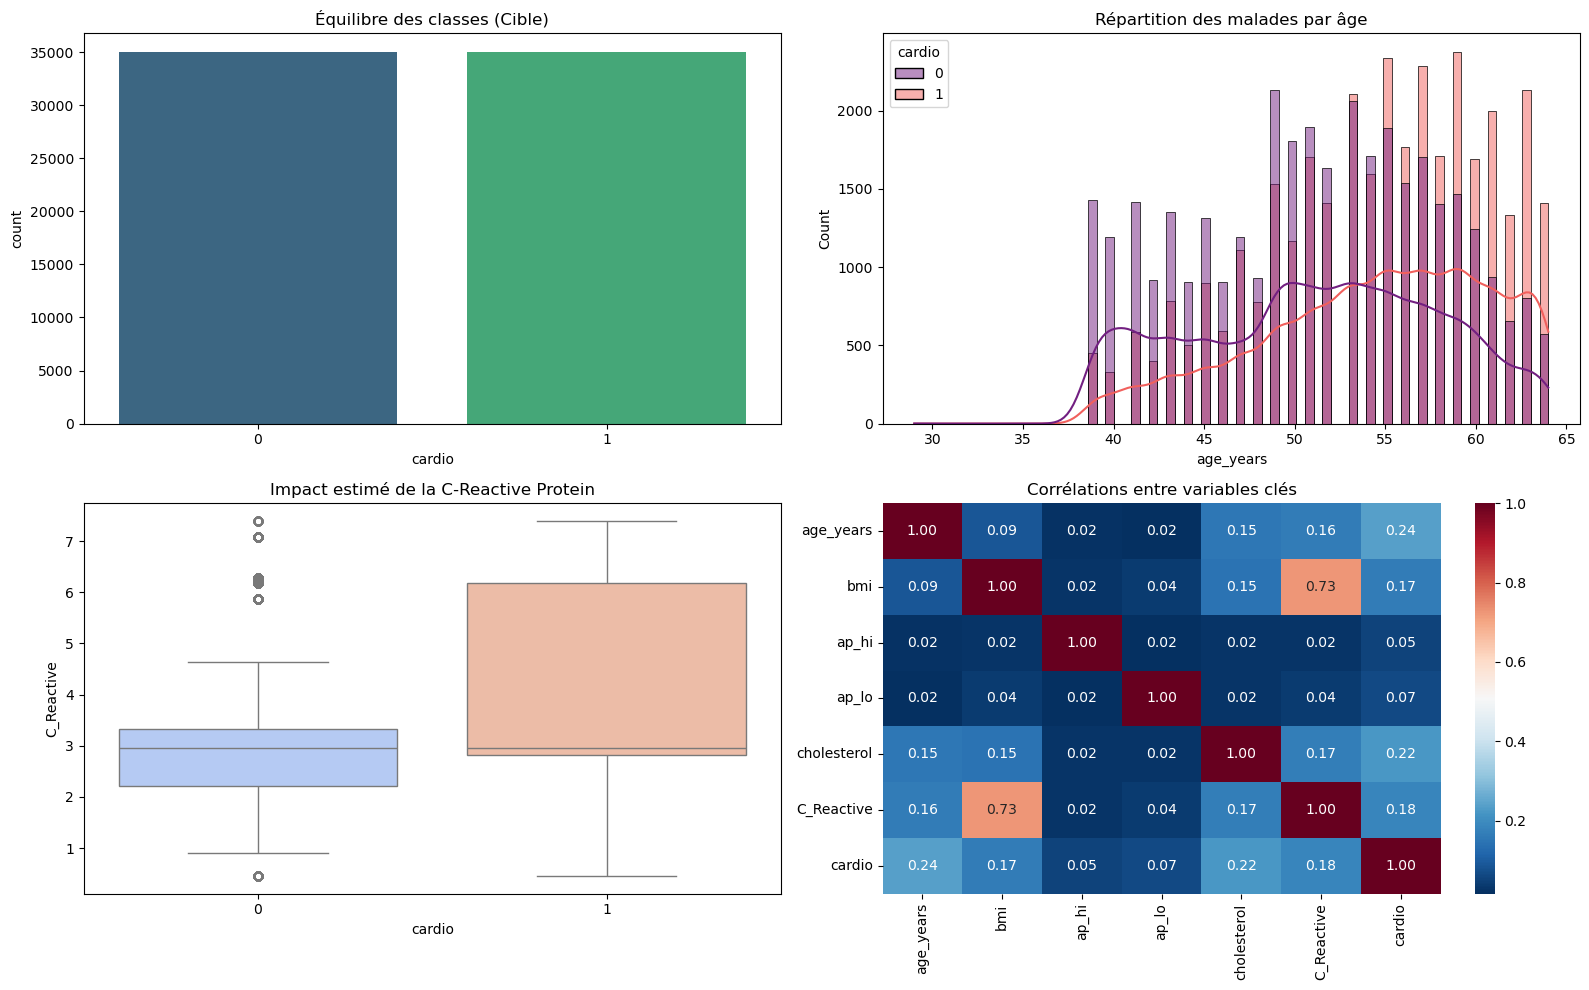

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/df_merged.csv")
# 1. Analyse des valeurs manquantes
missing_pct = (df.isnull().sum() / len(df)) * 100
print("--- % de valeurs manquantes ---")
print(missing_pct)

# 2. Visualisation
plt.figure(figsize=(16, 10))

# Sous-graphique 1 : Distribution de la cible
plt.subplot(2, 2, 1)
sns.countplot(x='cardio', data=df, palette='viridis')
plt.title('Équilibre des classes (Cible)')

# Sous-graphique 2 : Âge vs Cardio
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age_years', hue='cardio', kde=True, palette='magma')
plt.title('Répartition des malades par âge')

# Sous-graphique 3 : Boxplot C_Reactive (Nouvelle variable)
plt.subplot(2, 2, 3)
sns.boxplot(x='cardio', y='C_Reactive', data=df, palette='coolwarm')
plt.title('Impact estimé de la C-Reactive Protein')

# Sous-graphique 4 : Heatmap de corrélation
plt.subplot(2, 2, 4)
cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'C_Reactive', 'cardio']
sns.heatmap(df[cols].corr(), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Corrélations entre variables clés')

plt.tight_layout()
plt.show()